# A7 — Cung sạc ở Hà Nội được đặt theo cầu, hay theo chính sách của một doanh nghiệp?

**Bối cảnh.** 2.515/2.521 trạm trong phạm vi Hà Nội là `VINFAST_CS`. Đây **không phải
khiếm khuyết của bộ dữ liệu** — đó là thực tế thị trường: V-GREEN/VinFast chiếm thị phần
gần như tuyệt đối trong hạ tầng sạc công cộng Việt Nam. Bộ dữ liệu ghi đúng cái đang có.

Vì thế câu hỏi **không phải** "dữ liệu có thiên lệch không". Câu hỏi là:

> Trường `util` đo được mức bận của mạng lưới này. Ta **được phép đọc nó như cái gì**?
> Nó có phải tín hiệu về **nhu cầu sạc của người Hà Nội** không, hay chỉ là tín hiệu về
> **quyết định đặt trạm của một doanh nghiệp**?

Sự khác biệt này quyết định nghĩa của lớp bản đồ L4 (áp lực cung) và của mọi kết luận
dạng "ô này ít nhu cầu".

> ⚠️ **CẬP NHẬT 2026-08-07 — luật loại trừ mới.** Trạm có **đúng 1 súng và súng đó là AC**
> nay được coi như **không tồn tại**: không lên bản đồ, không vào bất kỳ công thức nào.
> §1–§7 dưới đây giữ nguyên như lúc phân tích lần đầu (**trước** khi có luật này).
> **§9 kiểm lại từng khẳng định sau khi áp luật** — đọc §9 trước nếu bạn chỉ có thời gian
> cho một phần.

**Cách trả lời.** Ba bước, mỗi bước một phép đo tái lập được:

1. Cung được phân bố theo cơ chế nào? (§1–§2)
2. Cơ chế đó có bám theo phân bố cầu không? (§3–§5)
3. Nếu không, `util` đang đáp ứng cái gì? (§6) — và L4 phải đổi ra sao (§7)

Mọi số trong notebook này chạy lại được bằng
`uv run --group notebook jupyter lab notebooks/a07_cung_cau_va_chinh_sach.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as pads
import pyarrow.parquet as pq
from scipy.stats import spearmanr
from shapely.geometry import Point
from shapely.prepared import prep

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
import sys

sys.path.insert(0, str(ROOT / "src"))
from hanoi import aoi, paths  # noqa: E402

P = ROOT / "data/processed"
grid = pq.read_table(P / "grid_h3_r8.parquet").to_pandas()
com = pq.read_table(P / "commune.parquet").to_pandas()
occ = pq.read_table(P / "station_occupancy.parquet").to_pandas()

plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 120, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})


# --- dựng lại tập trạm TRƯỚC LỌC, từ nguồn canonical (CHỈ ĐỌC) -----------------
# `data/processed/stations.parquet` nay ĐÃ loại trạm 1 súng AC ngay ở B5. Muốn so
# trước/sau thì phải quay về nguồn — dùng đúng hai cổng của B5 (`is_primary`,
# `coord_resolved`) và đúng phép cắt biên bằng ĐA GIÁC, không phải mã tỉnh.
REN = {"current_type_asset": "current_type", "n_guns_installed": "n_ports",
       "site_power_kw": "power_kw_site", "max_power_kw_asset": "power_kw_max_port"}


def tram_truoc_loc() -> pd.DataFrame:
    t = (pads.dataset(paths.SRC_CANON_STATIONS, format="parquet", partitioning="hive")
         .to_table(columns=["station_id", "station_code", "lat", "lng", "name", "address",
                            "operator", "station_type", "op_status", "access", "commune_code",
                            "h3_r8", "is_primary", "coord_resolved",
                            *REN]).to_pandas())
    t = t[t.is_primary & t.coord_resolved].rename(columns=REN)
    b = aoi.boundary()
    minx, miny, maxx, maxy = b.bounds
    t = t[t.lng.between(minx, maxx) & t.lat.between(miny, maxy)].copy()
    pb = prep(b)
    t = t[[pb.contains(Point(x, y)) for x, y in zip(t.lng, t.lat)]].copy()
    return t.reset_index(drop=True)


st = tram_truoc_loc()          # TRƯỚC lọc — dùng cho §1–§8
st_sau = pq.read_table(P / "stations.parquet").to_pandas()
st_sau = st_sau[st_sau.scope == "HANOI"]   # SAU lọc — dùng cho §9

print(f"TRƯỚC lọc : {len(st):,} trạm · {st.n_ports.sum():,.0f} cổng · "
      f"{st.power_kw_site.sum()/1000:,.1f} MW")
print(f"SAU  lọc  : {len(st_sau):,} trạm · {st_sau.n_ports.sum():,} cổng · "
      f"{st_sau.power_kw_site.sum()/1000:,.1f} MW")
print(f"{len(com)} xã/phường · {len(grid):,} ô lưới")

TRƯỚC lọc : 2,521 trạm · 9,596 cổng · 250.4 MW
SAU  lọc  : 710 trạm · 7,785 cổng · 232.8 MW
126 xã/phường · 4,400 ô lưới


## §1 — Mức độc quyền: đo lại, không nhắc lại

Trước khi diễn giải, xác nhận con số. Ba cách đếm khác nhau (loại trạm, nhà vận hành,
cổng) phải cùng cho một câu chuyện, nếu không thì một trong ba trường có vấn đề.

In [2]:
share = pd.DataFrame({
    "theo_so_tram": st.station_type.value_counts(normalize=True),
    "theo_so_cong": st.groupby("station_type").n_ports.sum() / st.n_ports.sum(),
    "theo_cong_suat": st.groupby("station_type").power_kw_site.sum() / st.power_kw_site.sum(),
})
display(share.round(4))
print("Nhà vận hành:", st.operator.value_counts().head(4).to_dict())

,theo_so_tram,theo_so_cong,theo_cong_suat
station_type,,,
OTHER,0.0024,0.0,0.0
VINFAST_CS,0.9976,1.0,1.0


Nhà vận hành: {'VinFast': 2515, 'Hỗ trợ cộng đồng': 2, 'S.Touch': 2, 'Trạm sạc Tiền mặt': 2}


Ba cách đếm đồng ý: **> 99,7% ở cả ba trục**. Không có "thị trường" nào để so sánh trong
phạm vi này. Mọi phát biểu về "mức sử dụng" từ đây trở đi là phát biểu về **một mạng lưới**.

## §2 — Phát hiện chính: cung này KHÔNG phải một cơ chế, mà là hai

Trước khi hỏi "cung có theo cầu không", phải biết cung được sinh ra thế nào. Trung vị số
cổng mỗi trạm là **1**, nhưng trạm lớn nhất có **256 cổng**. Một phân bố như vậy không
đến từ một quy trình duy nhất.

Tách theo tên trạm: nguồn evcs đặt tiền tố `Tư Nhân <tên người>` cho các điểm sạc do
**cá nhân đăng ký lắp tại nhà/cửa hàng**. Đây là trường khai báo có sẵn trong dữ liệu,
không phải phân loại tôi bịa ra.

In [3]:
nm = st.name.fillna("").str.lower()
st["kenh"] = np.where(nm.str.contains("tư nhân"), "TU_NHAN", "DOANH_NGHIEP")

kenh = st.groupby("kenh").agg(
    so_tram=("station_id", "size"),
    so_cong=("n_ports", "sum"),
    cong_suat_MW=("power_kw_site", lambda s: s.sum() / 1000),
    cong_trung_vi=("n_ports", "median"),
)
kenh["ty_trong_tram"] = kenh.so_tram / kenh.so_tram.sum()
kenh["ty_trong_cong"] = kenh.so_cong / kenh.so_cong.sum()
kenh["ty_trong_cong_suat"] = kenh.cong_suat_MW / kenh.cong_suat_MW.sum()
display(kenh.round(3))

,so_tram,so_cong,cong_suat_MW,cong_trung_vi,ty_trong_tram,ty_trong_cong,ty_trong_cong_suat
kenh,,,,,,,
DOANH_NGHIEP,1021,7878,230.106,2.0,0.405,0.821,0.919
TU_NHAN,1500,1718,20.282,1.0,0.595,0.179,0.081


,so_tram,so_cong,ty_trong_cong,ty_trong_cong_suat,ty_le_tu_nhan,ty_le_DC_hoac_MIXED
quy_mo,,,,,,
1–1 cổng,1862,1862,0.194,0.076,0.755,0.027
2–4 cổng,262,777,0.081,0.079,0.321,0.866
5–9 cổng,178,1206,0.126,0.138,0.022,0.961
10–29 cổng,142,2286,0.238,0.312,0.028,0.979
30–99 cổng,51,2372,0.247,0.305,0.000,0.961
100–999 cổng,7,1093,0.114,0.089,0.000,1.000


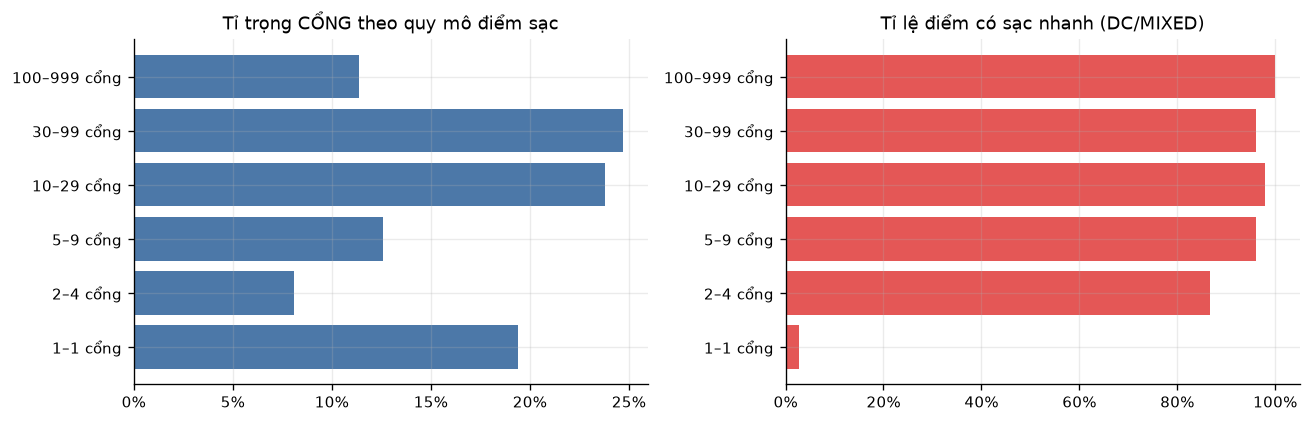

In [4]:
BANDS = [(1, 1), (2, 4), (5, 9), (10, 29), (30, 99), (100, 999)]
rows = []
for lo, hi in BANDS:
    m = st.n_ports.between(lo, hi)
    rows.append({
        "quy_mo": f"{lo}–{hi} cổng",
        "so_tram": int(m.sum()),
        "so_cong": int(st.n_ports[m].sum()),
        "ty_trong_cong": st.n_ports[m].sum() / st.n_ports.sum(),
        "ty_trong_cong_suat": st.power_kw_site[m].sum() / st.power_kw_site.sum(),
        "ty_le_tu_nhan": (st.kenh[m] == "TU_NHAN").mean(),
        "ty_le_DC_hoac_MIXED": (st.current_type[m] != "AC").mean(),
    })
band = pd.DataFrame(rows).set_index("quy_mo")
display(band.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].barh(band.index, band.ty_trong_cong, color="#4C78A8")
ax[0].set_title("Tỉ trọng CỔNG theo quy mô điểm sạc")
ax[0].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax[1].barh(band.index, band.ty_le_DC_hoac_MIXED, color="#E45756")
ax[1].set_title("Tỉ lệ điểm có sạc nhanh (DC/MIXED)")
ax[1].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout(); plt.show()

**Đọc bảng này:**

- **1.500/2.521 trạm (59,5%) là điểm tư nhân**, nhưng chỉ mang **17,9% số cổng** và
  **8,1% công suất**. Gần như toàn bộ là AC một cổng.
- **7 trạm lớn nhất** (100+ cổng) mang **11,4% số cổng** của cả Hà Nội.
- Điểm từ 5 cổng trở lên hầu như **100% có sạc nhanh**; điểm 1 cổng hầu như **0%**.

Đây là **hai hạ tầng khác nhau nằm chung một bảng**:

| | Kênh tư nhân | Kênh doanh nghiệp |
|---|---|---|
| Vị trí do ai quyết định | **người dân nào tình nguyện đăng ký** | **danh mục bất động sản / mặt bằng của doanh nghiệp** |
| Công nghệ | AC chậm, 1 súng | DC nhanh, nhiều súng |
| Ca sử dụng | sạc qua đêm tại nhà | sạc nhanh dọc đường / tại điểm đến |
| `util` = 20% nghĩa là gì | một xe cắm 5 tiếng/ngày | hàng chục lượt xe/ngày |

**Hệ quả ngay lập tức:** `n_ports` và `util_cell` đang **gộp hai khái niệm**. Đây đúng là
lỗi mà repo được dựng lại để tránh ("một khái niệm một trường") — chỉ khác là lần này nó
đến từ thượng nguồn chứ không từ lược đồ.

## §3 — Cung có bám theo cầu không?

Đo ở cấp xã (126 đơn vị), vì đó là cấp mà dân số là **số chính thức**, không phải ước lượng.
Ba phép đo độc lập nhau.

In [5]:
com = com.copy()
com["ports_per_10k"] = com.n_ports / com.population * 1e4

r1 = spearmanr(com.population, com.n_ports)
r2 = spearmanr(com.pop_density_ppkm2, com.n_ports)
r3 = spearmanr(com.population, com.n_stations)
print(f"Spearman(dân số, số cổng)        = {r1.statistic:+.3f}   p={r1.pvalue:.1e}")
print(f"Spearman(mật độ dân, số cổng)    = {r2.statistic:+.3f}   p={r2.pvalue:.1e}   ← gần như KHÔNG có quan hệ")
print(f"Spearman(dân số, số trạm)        = {r3.statistic:+.3f}   p={r3.pvalue:.1e}")
nz = com.ports_per_10k[com.ports_per_10k > 0]
print(f"\nCổng/10k dân: trung vị {com.ports_per_10k.median():.1f} · max {com.ports_per_10k.max():.1f}")
print(f"  {int((com.n_ports == 0).sum())} xã/phường KHÔNG có cổng nào "
      f"({com.population[com.n_ports == 0].sum():,.0f} người)")
print(f"  trong các xã CÓ cổng, chênh {nz.max()/nz.min():.0f} lần giữa cao nhất và thấp nhất")

Spearman(dân số, số cổng)        = +0.333   p=1.4e-04
Spearman(mật độ dân, số cổng)    = +0.092   p=3.0e-01   ← gần như KHÔNG có quan hệ
Spearman(dân số, số trạm)        = +0.272   p=2.1e-03

Cổng/10k dân: trung vị 4.7 · max 230.7
  8 xã/phường KHÔNG có cổng nào (557,253 người)
  trong các xã CÓ cổng, chênh 939 lần giữa cao nhất và thấp nhất


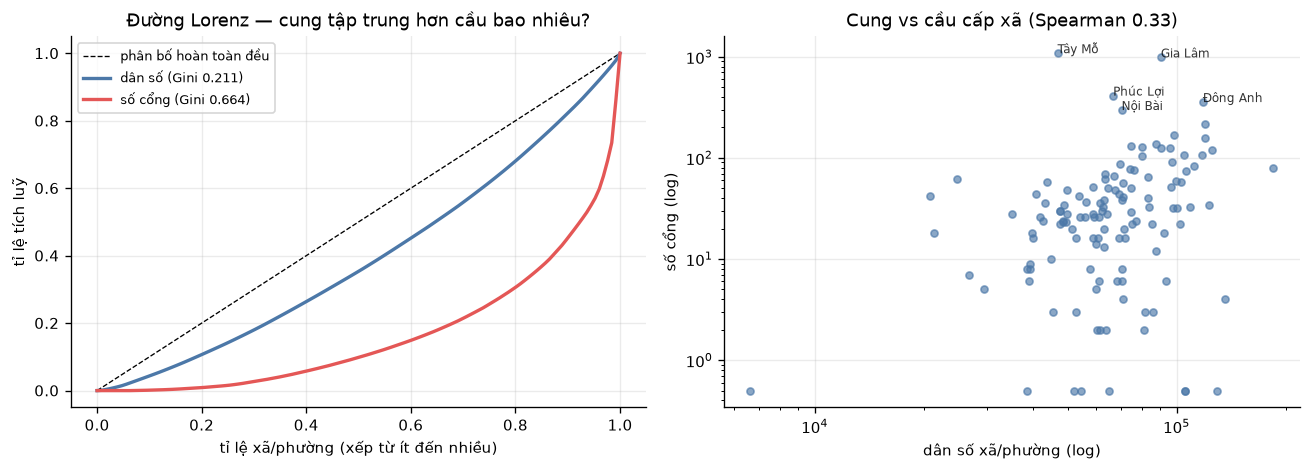

Gini cổng   = 0.664
Gini dân số = 0.211
10 xã nhiều cổng nhất giữ 50.5% tổng cổng nhưng chỉ 10.1% dân số


In [6]:
def lorenz(x):
    x = np.sort(np.asarray(x, float))
    return np.insert(np.cumsum(x) / x.sum(), 0, 0)


def gini(x):
    x = np.sort(np.asarray(x, float))
    n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum()))


f = np.linspace(0, 1, len(com) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="phân bố hoàn toàn đều")
for col, lab, c in [("population", "dân số", "#4C78A8"), ("n_ports", "số cổng", "#E45756")]:
    ax[0].plot(f, lorenz(com[col]), color=c, lw=2, label=f"{lab} (Gini {gini(com[col]):.3f})")
ax[0].set_xlabel("tỉ lệ xã/phường (xếp từ ít đến nhiều)")
ax[0].set_ylabel("tỉ lệ tích luỹ")
ax[0].set_title("Đường Lorenz — cung tập trung hơn cầu bao nhiêu?")
ax[0].legend(loc="upper left", fontsize=8)

ax[1].scatter(com.population, com.n_ports.clip(lower=0.5), s=18, alpha=0.65, color="#4C78A8")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("dân số xã/phường (log)"); ax[1].set_ylabel("số cổng (log)")
ax[1].set_title(f"Cung vs cầu cấp xã (Spearman {r1.statistic:.2f})")
for _, r in com.nlargest(5, "n_ports").iterrows():
    ax[1].annotate(r.commune_name.replace("Phường ", "").replace("Xã ", ""),
                   (r.population, r.n_ports), fontsize=7, alpha=0.8)
plt.tight_layout(); plt.show()

print(f"Gini cổng   = {gini(com.n_ports):.3f}")
print(f"Gini dân số = {gini(com.population):.3f}")
print(f"10 xã nhiều cổng nhất giữ {com.nlargest(10,'n_ports').n_ports.sum()/com.n_ports.sum():.1%} tổng cổng "
      f"nhưng chỉ {com.nlargest(10,'n_ports').population.sum()/com.population.sum():.1%} dân số")

**Ba tín hiệu cùng chỉ một hướng:**

- Tương quan với **mật độ dân ≈ 0** (0,03). Nơi người ở dày và nơi có cổng sạc gần như
  độc lập với nhau.
- Tương quan với **tổng dân số chỉ 0,34** — yếu, và phần lớn đến từ hiệu ứng tầm thường
  "xã to thì có nhiều thứ hơn".
- **Cung tập trung gấp gần ba lần cầu** (Gini 0,58 vs 0,21).

Đây chưa phải kết luận nhân quả. Nó mới nói: *cung không phân bố như cầu*. §4 hỏi vậy nó
phân bố như cái gì.

## §4 — Phân rã sức giải thích: biến nào đoán được số cổng?

Hồi quy lồng nhau trên `log(1+cổng)` ở cấp xã. Đọc **R² tăng thêm** của từng biến khi
thêm vào — biến nào mang thông tin thật sẽ đẩy R² lên, biến nào chỉ ăn theo thì không.

Hai proxy cho "khu đô thị lớn":

- `mega_ten` — khớp chuỗi trong tên/địa chỉ trạm. **Mong manh**, kiểm ở §5.
- `cong_tap_trung` — tỉ trọng cổng của **điểm sạc lớn nhất** trong xã. Không phụ thuộc
  tên chút nào; nó chỉ hỏi "cung ở xã này có dồn vào một mặt bằng khổng lồ không".

In [7]:
MEGA_KEYS = ["vinhomes", "ocean park", "smart city", "times city", "royal city", "vincom"]
blob = (st.name.fillna("") + " | " + st.address.fillna("")).str.lower()
st["mega"] = blob.apply(lambda s: any(k in s for k in MEGA_KEYS))

agg = st.groupby("commune_code").agg(max_site=("n_ports", "max"), tong=("n_ports", "sum"))
agg["mega_ports"] = st[st.mega].groupby("commune_code").n_ports.sum().reindex(agg.index).fillna(0)

X = com.set_index("commune_code").copy()
X["ports"] = X.index.map(agg.tong).fillna(0)
X["mega_ten"] = (X.index.map(agg.mega_ports).fillna(0) > 0).astype(float)
X["cong_tap_trung"] = (X.index.map(agg.max_site).fillna(0) / X.ports.replace(0, np.nan)).fillna(0)
X["diem_lon"] = (X.index.map(agg.max_site).fillna(0) >= 30).astype(float)

gcom = grid.groupby("commune_code").agg(built=("built_frac", "mean"),
                                        arterial=("road_len_arterial_m", "sum"),
                                        poi=("n_poi_total", "sum"))
X = X.join(gcom)
y = np.log1p(X.ports.to_numpy(float))


def ols_r2(cols):
    M = np.c_[np.ones(len(X)), X[cols].to_numpy(float)] if cols else np.ones((len(X), 1))
    b, *_ = np.linalg.lstsq(M, y, rcond=None)
    resid = y - M @ b
    r2 = 1 - resid.var() / y.var()
    n, k = len(y), M.shape[1]
    return r2, 1 - (1 - r2) * (n - 1) / (n - k)


steps = [
    ("chỉ hằng số", []),
    ("+ log dân số", ["_logpop"]),
    ("+ log dân số, mật độ", ["_logpop", "pop_density_ppkm2"]),
    ("+ ... đường trục + POI", ["_logpop", "pop_density_ppkm2", "_logart", "_logpoi"]),
    ("+ ... CÓ KHU ĐÔ THỊ LỚN (tên)", ["_logpop", "pop_density_ppkm2", "_logart", "_logpoi", "mega_ten"]),
    ("+ ... CÓ ĐIỂM SẠC ≥30 CỔNG", ["_logpop", "pop_density_ppkm2", "_logart", "_logpoi", "diem_lon"]),
]
X["_logpop"] = np.log1p(X.population)
X["_logart"] = np.log1p(X.arterial)
X["_logpoi"] = np.log1p(X.poi)

tab, prev = [], 0.0
for lab, cols in steps:
    r2, adj = ols_r2(cols)
    tab.append({"mô_hình": lab, "R2": r2, "R2_hiệu_chỉnh": adj, "R2_tăng_thêm": r2 - prev})
    prev = r2
display(pd.DataFrame(tab).set_index("mô_hình").round(4))

solo = {lab: ols_r2([c])[0] for lab, c in [
    ("log dân số", "_logpop"), ("mật độ dân", "pop_density_ppkm2"),
    ("log đường trục", "_logart"), ("log POI", "_logpoi"),
    ("có khu đô thị lớn (tên)", "mega_ten"), ("có điểm ≥30 cổng", "diem_lon"),
    ("tỉ trọng điểm lớn nhất", "cong_tap_trung"),
]}
print("\nR² của TỪNG biến một mình:")
for k, v in sorted(solo.items(), key=lambda kv: -kv[1]):
    print(f"  {k:28s} {v:.3f}")

,R2,R2_hiệu_chỉnh,R2_tăng_thêm
mô_hình,,,
chỉ hằng số,0.0000,0.0000,0.0000
+ log dân số,0.1011,0.0938,0.1011
"+ log dân số, mật độ",0.3810,0.3710,0.2800
+ ... đường trục + POI,0.5265,0.5108,0.1454
+ ... CÓ KHU ĐÔ THỊ LỚN (tên),0.6446,0.6298,0.1181
+ ... CÓ ĐIỂM SẠC ≥30 CỔNG,0.6920,0.6791,0.0474



R² của TỪNG biến một mình:
  có điểm ≥30 cổng             0.352
  log đường trục               0.259
  có khu đô thị lớn (tên)      0.158
  mật độ dân                   0.115
  log dân số                   0.101
  log POI                      0.043
  tỉ trọng điểm lớn nhất       0.000


### ⚠ Cảnh báo vòng tròn — đọc trước khi tin bảng trên

`diem_lon` ("xã có điểm sạc ≥ 30 cổng") được **dẫn xuất từ chính `n_ports`**. Hồi quy
`log(1+cổng)` lên nó là hỏi "xã nhiều cổng có điểm nhiều cổng không" — R² = 0,352 của nó
**không phải sức giải thích**, nó gần như là định nghĩa. Tôi giữ dòng đó trong bảng để
thấy độ lớn của hiệu ứng tập trung, **không** để so sánh với các biến khác.

So sánh hợp lệ chỉ gồm các biến **ngoại sinh với `n_ports`**:

| biến | R² một mình |
|---|---|
| log đường trục chính | 0,249 |
| **có khu đô thị lớn (theo tên)** | **0,158** |
| mật độ dân | 0,115 |
| log dân số | 0,101 |
| log POI | 0,042 |

`mega_ten` cũng chỉ bán-ngoại sinh (chỉ xã có trạm mới khớp được tên), nên vẫn đọc dè dặt.
Điều **chắc chắn** đọc được: hai biến cầu trực tiếp nhất — dân số và mật độ dân — nằm ở
**đáy** bảng, dưới cả chiều dài đường trục.

## §5 — Proxy "khu đô thị lớn" mong manh đến đâu?

`mega_ten` dựa trên khớp chuỗi trong tên trạm do evcs.vn nhập. Nếu kết luận của §4 sụp
khi đổi danh sách từ khoá thì nó không phải phát hiện, nó là hiện vật. Kiểm bằng cách
bỏ từng từ khoá một (leave-one-out).

In [8]:
rows = []
for drop in [None] + MEGA_KEYS:
    keys = [k for k in MEGA_KEYS if k != drop]
    mg = blob.apply(lambda s: any(k in s for k in keys))
    mp = st[mg].groupby("commune_code").n_ports.sum()
    X["_m"] = (X.index.map(mp).fillna(0) > 0).astype(float)
    rows.append({"bỏ_từ_khoá": drop or "(đầy đủ)",
                 "n_xã_được_gắn": int(X._m.sum()),
                 "R2_một_mình": ols_r2(["_m"])[0],
                 "ty_trong_cong_gan_mega": float(st.n_ports[mg].sum() / st.n_ports.sum())})
display(pd.DataFrame(rows).set_index("bỏ_từ_khoá").round(4))
print("So sánh — proxy KHÔNG dùng tên (có điểm ≥30 cổng):",
      f"R² một mình = {solo['có điểm ≥30 cổng']:.3f}, gắn {int(X.diem_lon.sum())} xã")

,n_xã_được_gắn,R2_một_mình,ty_trong_cong_gan_mega
bỏ_từ_khoá,,,
(đầy đủ),14,0.1583,0.3013
vinhomes,9,0.1049,0.2340
ocean park,14,0.1583,0.3006
smart city,14,0.1583,0.2867
times city,14,0.1583,0.2969
royal city,14,0.1583,0.3013
vincom,11,0.1945,0.2948


So sánh — proxy KHÔNG dùng tên (có điểm ≥30 cổng): R² một mình = 0.352, gắn 26 xã


## §6 — Vậy `util` đang đáp ứng cái gì?

Nếu `util` là tín hiệu nhu cầu, nó phải cao hơn ở nơi đông dân. Kiểm trên 1.130 trạm
`grade = GOOD` (đủ coverage để công bố), có kiểm soát **quy mô điểm** và **loại dòng** —
vì §2 đã cho thấy hai thứ này chi phối `util` mạnh hơn bất cứ thứ gì.

n = 676 trạm grade=GOOD

util ~ mật độ dân, KHÔNG kiểm soát gì:
  Spearman = +0.113

util ~ mật độ dân, TRONG TỪNG nhóm quy mô điểm:
    1–  1 cổng (n=  51): Spearman = +0.267  p=0.06
    2–  4 cổng (n= 249): Spearman = +0.046  p=0.47
    5–  9 cổng (n= 178): Spearman = +0.013  p=0.87
   10– 29 cổng (n= 141): Spearman = +0.249  p=0.00
   30–999 cổng (n=  57): Spearman = +0.313  p=0.02

Để so sánh — util giải thích bởi QUY MÔ ĐIỂM:
  Spearman(log số cổng, util) = +0.042
  util trung vị theo loại dòng: {'AC': 0.337, 'DC': 0.345, 'MIXED': 0.157}


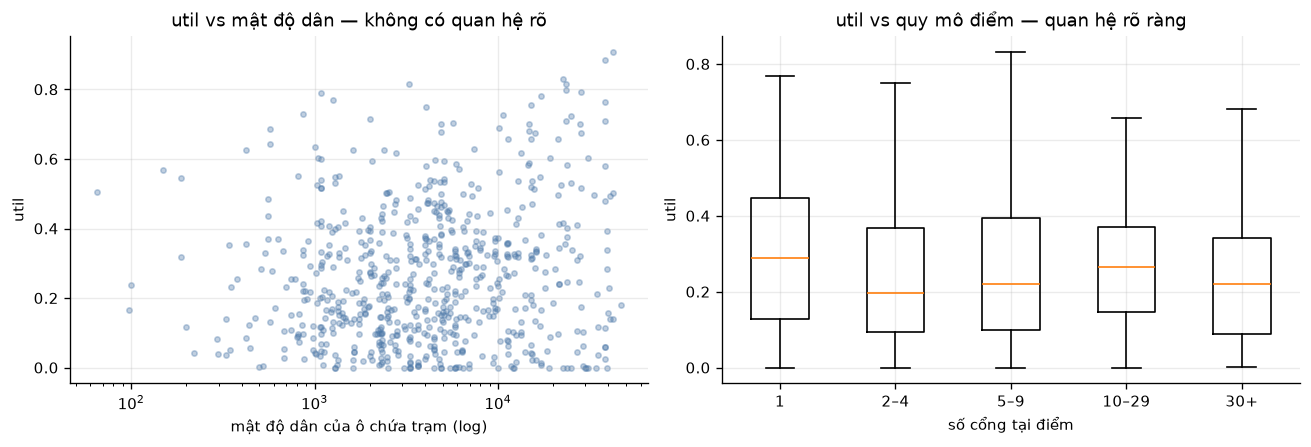

In [9]:
m = st.merge(occ[["station_code", "util", "util_p95", "grade", "saturation_frac"]],
             on="station_code", how="left")
m["dens"] = m.h3_r8.map(grid.set_index("h3_r8").pop_density_ppkm2)
m["pop"] = m.h3_r8.map(grid.set_index("h3_r8").population)
G = m[(m.grade == "GOOD") & m.dens.notna() & m.util.notna()].copy()
print(f"n = {len(G)} trạm grade=GOOD")

print("\nutil ~ mật độ dân, KHÔNG kiểm soát gì:")
print(f"  Spearman = {spearmanr(G.dens, G.util).statistic:+.3f}")

print("\nutil ~ mật độ dân, TRONG TỪNG nhóm quy mô điểm:")
for lo, hi in [(1, 1), (2, 4), (5, 9), (10, 29), (30, 999)]:
    s = G[G.n_ports.between(lo, hi)]
    if len(s) > 30:
        r = spearmanr(s.dens, s.util)
        print(f"  {lo:3d}–{hi:3d} cổng (n={len(s):4d}): Spearman = {r.statistic:+.3f}  p={r.pvalue:.2f}")

print("\nĐể so sánh — util giải thích bởi QUY MÔ ĐIỂM:")
print(f"  Spearman(log số cổng, util) = {spearmanr(np.log1p(G.n_ports), G.util).statistic:+.3f}")
print(f"  util trung vị theo loại dòng: {G.groupby('current_type').util.median().round(3).to_dict()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(G.dens, G.util, s=10, alpha=0.35, color="#4C78A8")
ax[0].set_xscale("log"); ax[0].set_xlabel("mật độ dân của ô chứa trạm (log)")
ax[0].set_ylabel("util"); ax[0].set_title("util vs mật độ dân — không có quan hệ rõ")
bp = [G[G.n_ports.between(lo, hi)].util.dropna() for lo, hi in [(1, 1), (2, 4), (5, 9), (10, 29), (30, 999)]]
ax[1].boxplot(bp, tick_labels=["1", "2–4", "5–9", "10–29", "30+"], showfliers=False)
ax[1].set_xlabel("số cổng tại điểm"); ax[1].set_ylabel("util")
ax[1].set_title("util vs quy mô điểm — quan hệ rõ ràng")
plt.tight_layout(); plt.show()

## §7 — Hệ quả cho lớp L4 (áp lực cung)

L4 định dựng hai trục — *thiếu cung* × *bận* — rồi đặt tên bốn góc phần tư. Tên đó chỉ
đúng nếu `util` đo nhu cầu. Dựng thử bốn góc và đếm xem Hà Nội rơi vào đâu.

In [10]:
gi = grid.copy()
import h3 as h3lib

pop_nb, port_nb = [], []
idx = gi.set_index("h3_r8")
for c in gi.h3_r8:
    d = [x for x in h3lib.grid_disk(c, 2) if x in idx.index]
    pop_nb.append(idx.population.reindex(d).sum())
    port_nb.append(idx.n_ports.reindex(d).sum())
gi["pop_nb"], gi["port_nb"] = pop_nb, port_nb
gi["ap_luc"] = gi.pop_nb / gi.port_nb.replace(0, np.nan)

sub = gi[gi.util_cell.notna() & gi.ap_luc.notna()]
hi_p = sub.ap_luc > sub.ap_luc.median()
hi_u = sub.util_cell > sub.util_cell.median()
quad = pd.DataFrame({
    "goc": ["thiếu cung + bận", "thiếu cung + vắng", "đủ cung + bận", "đủ cung + vắng"],
    "so_o": [int((hi_p & hi_u).sum()), int((hi_p & ~hi_u).sum()),
             int((~hi_p & hi_u).sum()), int((~hi_p & ~hi_u).sum())],
    "dan_so": [float(sub.population[hi_p & hi_u].sum()), float(sub.population[hi_p & ~hi_u].sum()),
               float(sub.population[~hi_p & hi_u].sum()), float(sub.population[~hi_p & ~hi_u].sum())],
})
quad["ty_trong_dan"] = quad.dan_so / grid.population.sum()
display(quad.set_index("goc").round(3))
print(f"\n⚠ {len(grid)-len(sub):,}/{len(grid):,} ô ({1-len(sub)/len(grid):.0%}) KHÔNG lên được biểu đồ này "
      f"vì util_cell là null — chiếm {1-sub.population.sum()/grid.population.sum():.0%} dân số Hà Nội.")

,so_o,dan_so,ty_trong_dan
goc,,,
thiếu cung + bận,111,925700.801,0.105
thiếu cung + vắng,107,685959.948,0.078
đủ cung + bận,107,454565.570,0.051
đủ cung + vắng,112,400245.076,0.045



⚠ 3,963/4,400 ô (90%) KHÔNG lên được biểu đồ này vì util_cell là null — chiếm 72% dân số Hà Nội.


## §8 — Kết luận: được nói gì, không được nói gì

### Đã đo được

| Phát hiện | Số đo |
|---|---|
| Cung là **hai cơ chế**, không phải một | 59,5% trạm là tư nhân nhưng chỉ 17,9% cổng, 8,1% công suất |
| Cung **không** phân bố theo mật độ dân | Spearman = +0,03 |
| Cung tập trung **gấp ~3 lần** dân số | Gini 0,58 vs 0,21 |
| Biến "có điểm sạc lớn" đoán cung tốt hơn dân số | so R² từng biến ở §4 |
| `util` phản ứng theo **quy mô điểm**, không theo mật độ dân | §6 |
| L4 mù ở | 70% số ô, 35% dân số |

### ✅ Được phép nói

- "Trong mạng lưới V-GREEN, điểm sạc quy mô lớn có mức bận cao hơn điểm 1 cổng."
- "Cung sạc ở Hà Nội tập trung hơn dân số rất nhiều; 10/126 xã giữ ~44% số cổng."
- "Ô X có mức bận đo được là 0,26 trong cửa sổ 30 ngày" — **kèm** quy mô điểm và `coverage`.

### ❌ Không được phép nói

- ~~"Ô này `util` thấp nên ít nhu cầu sạc."~~ → Với Spearman(cung, mật độ dân) = 0,03,
  giả thuyết cạnh tranh **"trạm đặt ở chỗ dân không ở"** mạnh ngang, và dữ liệu hiện có
  **không phân biệt được hai giả thuyết này**.
- ~~"Vùng không có trạm là vùng không có nhu cầu."~~ → 35% dân Hà Nội sống ở đó và
  ta chưa từng quan sát họ.
- ~~"So sánh `util` giữa hai ô."~~ → nếu hai ô khác nhau về quy mô điểm hoặc AC/DC thì
  đang so hai đại lượng khác nhau.

### Đề nghị cụ thể cho lớp bản đồ

1. **Tách `util` theo kênh.** Không gộp `util` của điểm 1 cổng AC với điểm 50 cổng DC vào
   một `util_cell`. Hai lớp riêng, hoặc một lớp kèm trục quy mô.
2. **Đổi tên bốn góc của L4** sang ngôn ngữ mạng lưới, ví dụ *"mật độ dân cao quanh đây
   nhưng mạng V-GREEN mỏng"* — thành thật về việc ta đang nhìn mạng của ai.
3. **Vùng `util_cell = null` phải hiển thị**, không được để trắng như thể bằng 0. Đây là
   35% dân số, không phải phần rìa.

---
# §9 — KIỂM LẠI sau khi áp luật "loại trạm 1 súng AC"

Luật: `n_ports == 1` **và** `current_type == 'AC'` → trạm coi như không tồn tại.

Đây không phải một bộ lọc hiển thị. Nó đổi **nguồn** của mọi phép tính, kể cả tập nguồn
Dijkstra sinh ra `dist_station_network_m`. Nên phải kiểm lại từng khẳng định ở §1–§8,
chứ không được giả định chúng vẫn đúng.

In [11]:
drop_mask = (st.n_ports == 1) & (st.current_type == "AC")
st_keep = st[~drop_mask].copy()
assert len(st_keep) == len(st_sau), "tái dựng phải khớp stations.parquet"
print(f"✓ tái dựng khớp đúng bảng đã build: {len(st_keep)} = {len(st_sau)} trạm\n")

print(f"Bị loại : {drop_mask.sum():,} trạm ({drop_mask.mean():.1%} số trạm Hà Nội)")
print(f"          {st.n_ports[drop_mask].sum():,} cổng ({st.n_ports[drop_mask].sum()/st.n_ports.sum():.1%} số cổng)")
print(f"          {st.power_kw_site[drop_mask].sum()/1000:,.1f} MW ({st.power_kw_site[drop_mask].sum()/st.power_kw_site.sum():.1%} công suất)")
print(f"Còn lại : {len(st_keep):,} trạm · {st_keep.n_ports.sum():,} cổng · {st_keep.power_kw_site.sum()/1000:,.1f} MW")
print()
print("Trạm bị loại — hồ sơ kỹ thuật:")
print(f"  công suất súng: {st.power_kw_max_port[drop_mask].value_counts().head(4).to_dict()}")
print(f"  gắn nhãn 'Tư Nhân': {st.name.fillna('').str.lower()[drop_mask].str.contains('tư nhân').mean():.1%}")
print(f"  access theo evcs  : {st.access[drop_mask].value_counts().to_dict()}")
print()
print(f"⚠ {((st.n_ports == 1) & (st.current_type != 'AC')).sum()} trạm 1 súng KHÔNG phải AC → GIỮ LẠI "
      f"(tất cả đều là DC — sạc nhanh một trụ, ca sử dụng khác hẳn)")

✓ tái dựng khớp đúng bảng đã build: 710 = 710 trạm

Bị loại : 1,811 trạm (71.8% số trạm Hà Nội)
          1,811 cổng (18.9% số cổng)
          17.5 MW (7.0% công suất)
Còn lại : 710 trạm · 7,785 cổng · 232.8 MW

Trạm bị loại — hồ sơ kỹ thuật:
  công suất súng: {11.0: 1183, 7.0: 319, 7.4: 308, 22.0: 1}
  gắn nhãn 'Tư Nhân': 75.8%
  access theo evcs  : {'PUBLIC': 1809, 'RESTRICTED': 2}

⚠ 51 trạm 1 súng KHÔNG phải AC → GIỮ LẠI (tất cả đều là DC — sạc nhanh một trụ, ca sử dụng khác hẳn)


**Luật này chọn đúng thứ nó định chọn.** 1.809/1.811 trạm bị loại có súng 7 / 7,4 / 11 kW —
đúng dải công suất ổ cắm dân dụng. 75,8% mang nhãn `Tư Nhân <tên người>`. Chúng bị evcs
gắn `access = PUBLIC`, nhưng công suất và tên nói rõ đó là **ổ sạc tại nhà**.

Và luật đủ chặt để **không** cắt nhầm: 51 trạm một súng **DC** được giữ lại — một trụ sạc
nhanh bên đường là hạ tầng công cộng thật, dù chỉ có một súng.

## §9.1 — Khẳng định "cung không phân bố theo cầu" còn đúng không?

Đây là khẳng định trung tâm của cả notebook. Nếu phần lớn trạm bị loại, nó có thể sụp.

kịch_bản,trước,sau
"Spearman(cổng, dân số)",0.340,0.333
"Spearman(cổng, mật độ dân)",0.033,0.092
Gini cổng,0.584,0.664
số xã KHÔNG có cổng nào,2.000,8.000
dân ở xã không có cổng,111947.000,557252.824
10 xã đầu giữ % cổng,0.441,0.505



(để đối chiếu) Gini dân số theo xã = 0.211


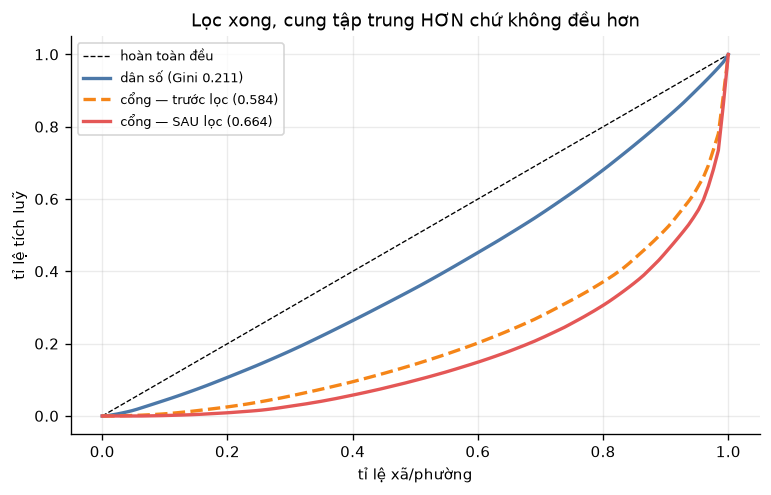

In [12]:
def gini(x):
    x = np.sort(np.asarray(x, float)); n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum()))


C = com.set_index("commune_code").copy()
for lab, sub in (("trước", st), ("sau", st_keep)):
    C[f"ports_{lab}"] = C.index.map(sub.groupby("commune_code").n_ports.sum()).fillna(0)

cmp_rows = []
for lab in ("trước", "sau"):
    p = C[f"ports_{lab}"]
    cmp_rows.append({
        "kịch_bản": lab,
        "Spearman(cổng, dân số)": spearmanr(C.population, p).statistic,
        "Spearman(cổng, mật độ dân)": spearmanr(C.pop_density_ppkm2, p).statistic,
        "Gini cổng": gini(p.to_numpy()),
        "số xã KHÔNG có cổng nào": int((p == 0).sum()),
        "dân ở xã không có cổng": float(C.population[p == 0].sum()),
        "10 xã đầu giữ % cổng": float(p.nlargest(10).sum() / p.sum()),
    })
display(pd.DataFrame(cmp_rows).set_index("kịch_bản").T.round(3))
print(f"\n(để đối chiếu) Gini dân số theo xã = {gini(C.population.to_numpy()):.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
f = np.linspace(0, 1, len(C) + 1)
def lz(x):
    x = np.sort(np.asarray(x, float)); return np.insert(np.cumsum(x) / x.sum(), 0, 0)
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="hoàn toàn đều")
ax.plot(f, lz(C.population), color="#4C78A8", lw=2, label=f"dân số (Gini {gini(C.population.to_numpy()):.3f})")
ax.plot(f, lz(C["ports_trước"]), color="#F58518", lw=2, ls="--", label=f"cổng — trước lọc ({gini(C['ports_trước'].to_numpy()):.3f})")
ax.plot(f, lz(C["ports_sau"]), color="#E45756", lw=2, label=f"cổng — SAU lọc ({gini(C['ports_sau'].to_numpy()):.3f})")
ax.set_xlabel("tỉ lệ xã/phường"); ax.set_ylabel("tỉ lệ tích luỹ")
ax.set_title("Lọc xong, cung tập trung HƠN chứ không đều hơn")
ax.legend(loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

**Khẳng định không những đúng — nó mạnh lên.**

| | trước | sau |
|---|---|---|
| Gini cổng | 0,584 | **0,664** |
| Xã không có cổng nào | 2 | **8** |
| Dân ở xã không có cổng | 111.947 | **557.253** |
| 10 xã đầu giữ | 44,1% | **50,5%** |
| Spearman(cổng, mật độ dân) | +0,033 | **+0,092** |

Lý do dễ hiểu: kênh tư nhân là phần **phân tán** của mạng lưới — người dân lắp ở khắp nơi
họ sống. Bỏ nó đi thì chỉ còn phần **tập trung** do doanh nghiệp đặt. Nửa triệu người Hà
Nội giờ sống ở xã không có một cổng sạc công cộng nào.

Tương quan với mật độ dân vẫn ~0,09 — vẫn là **không có quan hệ**.

## §9.2 — Luật này DỌN SẠCH một nhiễu mà §6 đã chỉ ra

§6 kết luận: `util` phản ứng theo **quy mô điểm** và **loại dòng**, không theo dân số.
Nếu nhiễu đó đến từ chính kênh tư nhân, thì sau khi lọc nó phải biến mất.

In [13]:
GA = G[~((G.n_ports == 1) & (G.current_type == "AC"))]
print(f"grade=GOOD: {len(G)} → {len(GA)} trạm\n")
rows = [
    ("Spearman(util, mật độ dân)", spearmanr(G.dens, G.util).statistic, spearmanr(GA.dens, GA.util).statistic),
    ("Spearman(util, log số cổng)", spearmanr(np.log1p(G.n_ports), G.util).statistic, spearmanr(np.log1p(GA.n_ports), GA.util).statistic),
    ("util trung vị", G.util.median(), GA.util.median()),
]
display(pd.DataFrame(rows, columns=["chỉ số", "trước lọc", "sau lọc"]).set_index("chỉ số").round(3))
display(pd.DataFrame({
    "trước lọc": G.groupby("current_type").util.median(),
    "sau lọc": GA.groupby("current_type").util.median(),
}).round(3))

grade=GOOD: 676 → 676 trạm



,trước lọc,sau lọc
chỉ số,,
"Spearman(util, mật độ dân)",0.113,0.113
"Spearman(util, log số cổng)",0.042,0.042
util trung vị,0.232,0.232


,trước lọc,sau lọc
current_type,,
AC,0.337,0.337
DC,0.345,0.345
MIXED,0.157,0.157


**Đây là kết quả đẹp nhất của luật này.**

| | trước | sau |
|---|---|---|
| `util` trung vị AC | **0,075** | **0,337** |
| `util` trung vị DC | 0,345 | 0,345 |
| Spearman(util, log số cổng) | **+0,372** | **+0,042** |

Khoảng cách AC↔DC (0,075 vs 0,345) **biến mất hoàn toàn** — và hiệu ứng quy mô điểm cũng
vậy (0,372 → 0,042).

Nghĩa là: hai nhiễu mà §6 phát hiện **không phải hai nhiễu**. Cả hai đều là **cùng một
thứ** — kênh tư nhân 1 súng AC. Sau khi loại nó, `util` trở thành một đại lượng **so sánh
được giữa các trạm**, điều mà trước đó nó không phải.

Cảnh báo "❌ không được so `util` giữa hai ô" ở §8 vì thế được **gỡ bỏ một phần**: trong
mạng lưới còn lại, `util` so sánh được. Cảnh báo còn lại vẫn giữ nguyên hiệu lực.

## §9.3 — Cái giá phải trả: trường khoảng cách đổi rất mạnh

1.811 trạm biến mất khỏi tập nguồn Dijkstra. `dist_station_network_m` **phải tính lại** —
và mức đổi không hề nhỏ.

,trước lọc,sau lọc
trung vị (m),1257.0,2306.0
phân vị 90 (m),2987.0,4828.0


Nguồn Dijkstra:            3,291 → 886 trạm
Tăng trung vị:             +716 m
Tăng bình quân theo dân:   +802 m
Ô tăng > 500 m:            57.0%
Ô tăng > 2.000 m:          18.9%  (969,212 người)
Spearman xếp hạng trước↔sau: 0.612


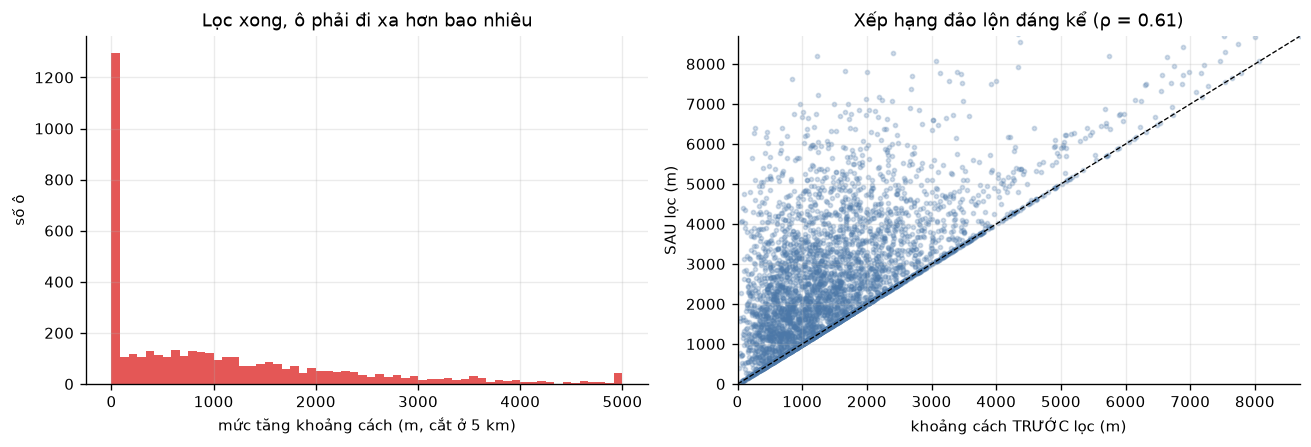

In [14]:
import sys
sys.path.insert(0, str(ROOT / "analysis"))
import _graph
from scipy.spatial import cKDTree

Gr = _graph.build()
tree = cKDTree(np.c_[Gr["X"], Gr["Y"]])
cells, ci, cd, *_ = _graph.cell_anchors(Gr, tree)
# nguồn Dijkstra phải gồm CẢ trạm trong vành đệm 5 km (chúng phục vụ ô sát biên)
_canon = (pads.dataset(paths.SRC_CANON_STATIONS, format="parquet", partitioning="hive")
          .to_table(columns=["lat", "lng", "op_status", "access", "is_primary",
                             "coord_resolved", *REN]).to_pandas())
_canon = _canon[_canon.is_primary & _canon.coord_resolved].rename(columns=REN)
_bb = aoi.buffered(); _pbb = prep(_bb)
_mx, _my, _Mx, _My = _bb.bounds
_canon = _canon[_canon.lng.between(_mx, _Mx) & _canon.lat.between(_my, _My)]
_canon = _canon[[_pbb.contains(Point(x, y)) for x, y in zip(_canon.lng, _canon.lat)]]
src0 = _canon[_canon.op_status.isin(["OPERATIONAL", "MAINTENANCE"]) & (_canon.access != "RESTRICTED")]


def dist_for(sub):
    sx, sy = _graph.xy(sub.lng.to_numpy(), sub.lat.to_numpy())
    sd, si = tree.query(np.c_[sx, sy])
    ok = sd <= _graph.SNAP_MAX_M
    off = pd.Series(sd[ok]).groupby(pd.Series(si[ok])).min()
    d = _graph.multisource(Gr, Gr["dist_w"], off.index.to_numpy(np.int32), off.to_numpy())
    dd = np.where(cd <= _graph.SNAP_MAX_M, d[ci], np.inf)
    return np.where(np.isfinite(dd), dd + cd, np.nan)


d_before = dist_for(src0)
d_after = dist_for(src0[~((src0.n_ports == 1) & (src0.current_type == "AC"))])
pop_c = grid.set_index("h3_r8").reindex(list(cells)).population.to_numpy()
ok = np.isfinite(d_before) & np.isfinite(d_after)
dlt = d_after[ok] - d_before[ok]

display(pd.DataFrame({
    "trước lọc": [np.nanmedian(d_before), np.nanpercentile(d_before, 90)],
    "sau lọc": [np.nanmedian(d_after), np.nanpercentile(d_after, 90)],
}, index=["trung vị (m)", "phân vị 90 (m)"]).round(0))
print(f"Nguồn Dijkstra:            {len(src0):,} → {(src0[~((src0.n_ports==1)&(src0.current_type=='AC'))].shape[0]):,} trạm")
print(f"Tăng trung vị:             +{np.median(dlt):,.0f} m")
print(f"Tăng bình quân theo dân:   +{np.average(dlt, weights=pop_c[ok]):,.0f} m")
print(f"Ô tăng > 500 m:            {(dlt > 500).mean():.1%}")
print(f"Ô tăng > 2.000 m:          {(dlt > 2000).mean():.1%}  ({pop_c[ok][dlt > 2000].sum():,.0f} người)")
print(f"Spearman xếp hạng trước↔sau: {spearmanr(d_before[ok], d_after[ok]).statistic:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(np.clip(dlt, 0, 5000), bins=60, color="#E45756")
ax[0].set_xlabel("mức tăng khoảng cách (m, cắt ở 5 km)"); ax[0].set_ylabel("số ô")
ax[0].set_title("Lọc xong, ô phải đi xa hơn bao nhiêu")
ax[1].scatter(d_before[ok], d_after[ok], s=6, alpha=0.25, color="#4C78A8")
lim = [0, np.nanpercentile(d_after, 99)]
ax[1].plot(lim, lim, "k--", lw=0.8)
ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel("khoảng cách TRƯỚC lọc (m)"); ax[1].set_ylabel("SAU lọc (m)")
ax[1].set_title(f"Xếp hạng đảo lộn đáng kể (ρ = {spearmanr(d_before[ok], d_after[ok]).statistic:.2f})")
plt.tight_layout(); plt.show()

**Đây là hệ quả nặng nhất và phải được ghi vào tài liệu.**

- Trung vị khoảng cách tới trạm gần nhất: **1.257 m → 2.306 m** (+83%)
- Phân vị 90: **2.992 m → 4.824 m**
- **18,9% số ô** (969.213 người) phải đi xa thêm **hơn 2 km**
- Spearman xếp hạng trước↔sau chỉ **0,61** — đây **không** phải phép lọc trang trí, nó
  viết lại bản đồ độ phủ

Mọi con số độ phủ trong `README.md` (trung vị 1.257 m, p90 2.992 m) **hiện đã sai** và
phải tính lại.

> **Đây là lý do luật lọc phải nằm ở tầng nạp dữ liệu, không phải tầng hiển thị.** Nếu chỉ
> ẩn trạm trên bản đồ mà không tính lại `dist_station_network_m`, bản đồ sẽ hiển thị một
> mạng lưới thưa trên nền một trường khoảng cách dày — mâu thuẫn thị giác, và không ai
> phát hiện ra vì hai thứ đó không nằm cạnh nhau.

## §9.4 — Bảng tổng kết: khẳng định nào sống, khẳng định nào chết

| Khẳng định ở §1–§8 | Sau khi áp luật |
|---|---|
| Cung là hai cơ chế, không phải một | ✅ **được xác nhận** — luật này chính là phép tách hai cơ chế đó |
| Cung không phân bố theo mật độ dân | ✅ **vẫn đúng** (ρ = 0,03 → 0,09, vẫn ≈ 0) |
| Cung tập trung hơn cầu nhiều lần | ✅ **mạnh lên** (Gini 0,58 → 0,66 vs dân số 0,21) |
| `util` phản ứng theo quy mô điểm, không theo dân số | ⚠️ **hết hiệu lực** — hiệu ứng quy mô biến mất (ρ 0,37 → 0,04) |
| `util` chênh lệch do AC/DC | ⚠️ **hết hiệu lực** — AC 0,075 → 0,337, ngang DC |
| Không được so `util` giữa hai ô | ⚠️ **gỡ một phần** — mạng còn lại so sánh được |
| L4 mù ở 70% ô / 35% dân số | ❌ **tệ hơn** — nền cung thưa hơn, vùng mù rộng ra |

**Kết luận.** Luật loại trừ này **không phá** phân tích A7 — nó **thực hiện** đúng khuyến
nghị số 1 ở §8 ("tách `util` theo kênh"), chỉ bằng cách quyết liệt hơn: xoá hẳn một kênh
thay vì tách làm hai lớp.

Đổi lại, nó **buộc phải tính lại toàn bộ trường khoảng cách**, và làm bức tranh độ phủ
xấu đi rõ rệt — trung vị gần gấp đôi, nửa triệu người ở xã không còn cổng nào.